## cheaseBS iteration_00 — output check & input/output comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline as US
from scipy import interpolate
from freeqdsk import geqdsk
%matplotlib inline

# --- paths (from run_cheaseBS notebook) ---
DATA_DIR   = '/global/homes/j/joeschm/projects/cheaseBS_tests/data/129015_runs/profile_data'
EQDSK_IN   = DATA_DIR + '/g129015.00409_450'
PROF_E     = DATA_DIR + '/profiles_e_129015'
PROF_I     = DATA_DIR + '/profiles_i_129015'
PROF_Z     = DATA_DIR + '/profiles_z_129015'

ART_DIR    = 'runs/iterative/iteration_00/artifacts'
EQDSK_OUT  = ART_DIR + '/EQDSK_COCOS_02_POS.OUT'
EXPTNZ     = ART_DIR + '/EXPTNZ'

In [2]:
# --- Read both g-eqdsk files with freeqdsk ---
def read_geqdsk(path):
    with open(path) as f:
        d = geqdsk.read(f)
    nw = d.nw
    nh = d.nh
    pn = np.linspace(0, 1, nw)
    return dict(
        nw=nw, nh=nh,
        Rg=np.array(d.r_grid), Zg=np.array(d.z_grid),
        rmag=d.rmagx, zmag=d.zmagx,
        psiax=d.simagx, psisep=d.sibdry,
        Bctr=d.bcentr,
        F=np.array(d.fpol),
        p=np.array(d.pres),
        ffp=np.array(d.ffprime),
        pp=np.array(d.pprime),
        psirz=np.array(d.psirz),
        q=np.array(d.qpsi),
        pn=pn,
        rbbbs=np.array(d.rbbbs),
        zbbbs=np.array(d.zbbbs),
    )

IN  = read_geqdsk(EQDSK_IN)
OUT = read_geqdsk(EQDSK_OUT)
print(f"Input  nw={IN['nw']}, rmag={IN['rmag']:.4f}, psiax={IN['psiax']:.4f}, psisep={IN['psisep']:.4f}")
print(f"Output nw={OUT['nw']}, rmag={OUT['rmag']:.4f}, psiax={OUT['psiax']:.4f}, psisep={OUT['psisep']:.4f}")

Input  nw=129, rmag=0.9458, psiax=-0.0548, psisep=0.0148
Output nw=513, rmag=0.9461, psiax=-0.0874, psisep=0.0000


### 1 — EQDSK: q, fpol, pprime, pres, ffprime (input vs output)

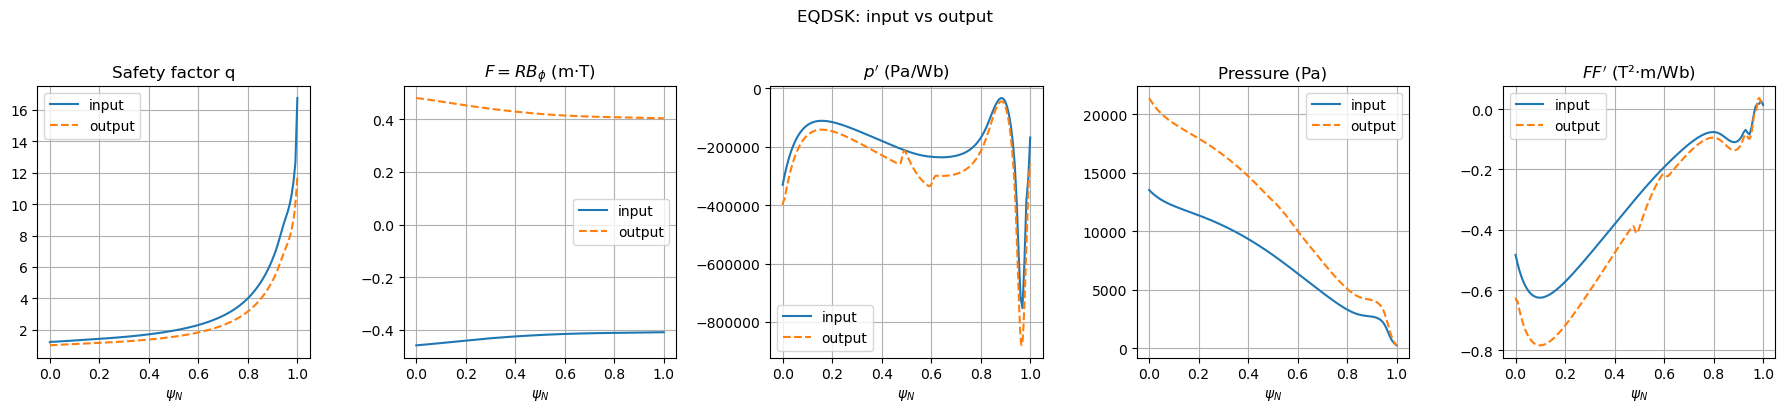

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
pairs = [
    ('q',   'Safety factor q'),
    ('F',   r'$F=RB_\phi$ (m·T)'),
    ('pp',  r"$p'$ (Pa/Wb)"),
    ('p',   r'Pressure (Pa)'),
    ('ffp', r"$FF'$ (T²·m/Wb)"),
]
for ax, (key, lbl) in zip(axes, pairs):
    ax.plot(IN['pn'],  IN[key],  label='input')
    ax.plot(OUT['pn'], OUT[key], label='output', ls='--')
    ax.set_xlabel(r'$\psi_N$'); ax.set_title(lbl); ax.legend(); ax.grid(True)
plt.suptitle('EQDSK: input vs output', y=1.02)
plt.tight_layout(); plt.show()

### 2 — Flux surface contours (input vs output)

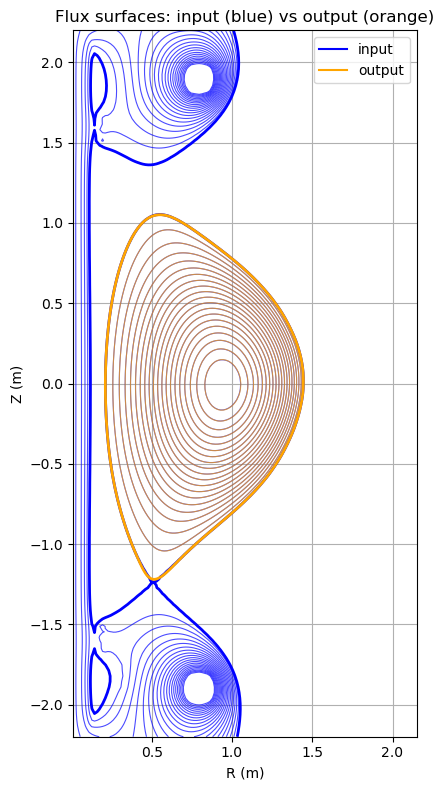

In [4]:
fig, ax = plt.subplots(figsize=(6, 8))
levels = np.linspace(0, 1, 21)
for d, color, label in [(IN, 'blue', 'input'), (OUT, 'orange', 'output')]:
    pn2d = (d['psirz'] - d['psiax']) / (d['psisep'] - d['psiax'])
    ax.contour(d['Rg'], d['Zg'], pn2d, levels=levels, colors=color, alpha=0.7,
               linewidths=0.8)
    # LCFS
    ax.contour(d['Rg'], d['Zg'], pn2d, levels=[1.0], colors=color, linewidths=2)
    ax.plot([], [], color=color, label=label)  # legend proxy
ax.set_xlabel('R (m)'); ax.set_ylabel('Z (m)')
ax.set_title('Flux surfaces: input (blue) vs output (orange)')
ax.set_aspect('equal'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

### 3 — Profiles: Te, ne (input profiles_e vs EXPTNZ output)

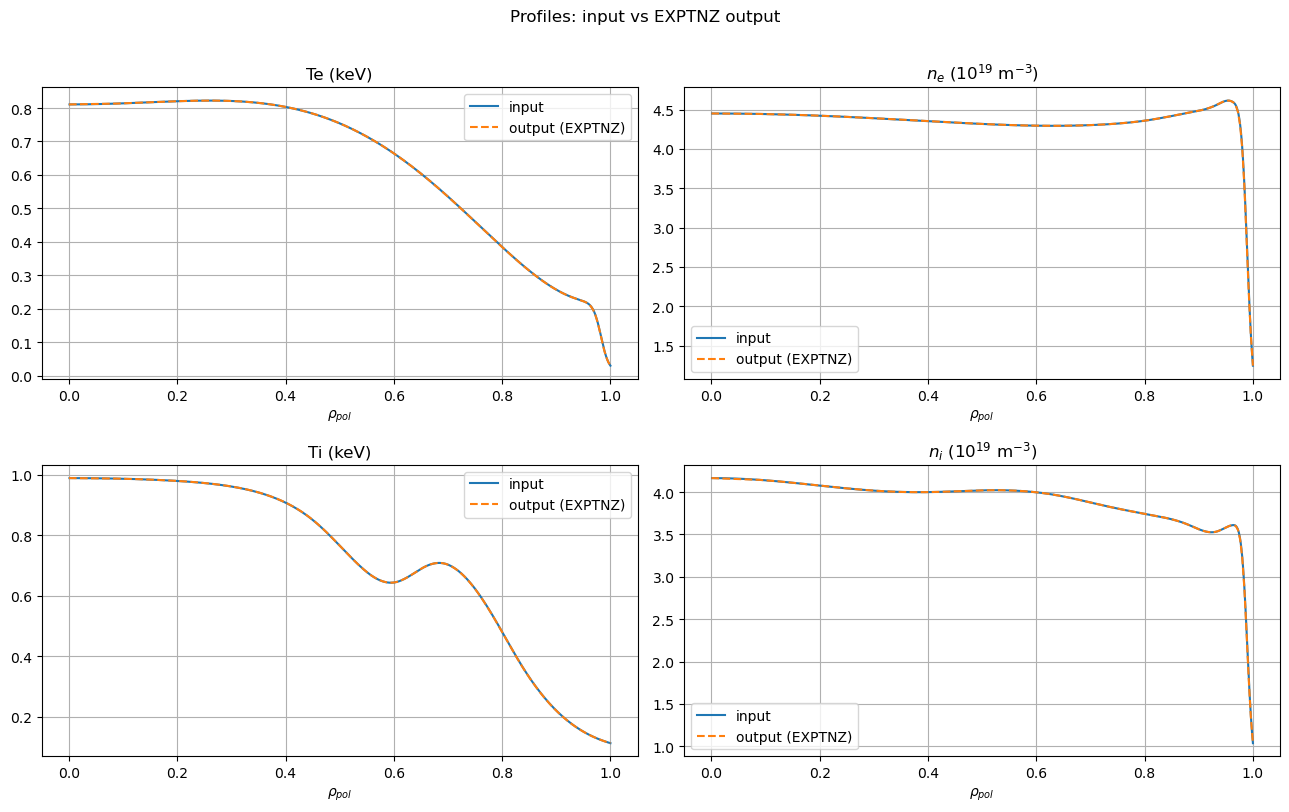

In [5]:
# Load input profiles (skip comment lines starting with #)
pe = np.loadtxt(PROF_E, comments='#')   # rho_tor, rho_pol, Te[keV], ne[1e19 m^-3]
pi = np.loadtxt(PROF_I, comments='#')   # rho_tor, rho_pol, Ti[keV], ni[1e19 m^-3]
pz = np.loadtxt(PROF_Z, comments='#')   # rho_tor, rho_pol, Ti[keV], nz[1e19 m^-3]

# Load EXPTNZ output
# Format: header line, then rho_pol grid (129 pts), Te, ne, Zeff, Ti, ni
with open(EXPTNZ) as f:
    raw = f.readlines()
header = raw[0]   # '129   rhopsi, Te, ne, Zeff, Ti, ni profiles'
npts = int(header.split()[0])
vals = np.array([float(x) for line in raw[1:] for x in line.split()])
# layout: rho_pol(npts), Te(npts), ne(npts), Zeff(npts), Ti(npts), ni(npts)
rp_out = vals[0*npts:1*npts]
Te_out = vals[1*npts:2*npts]
ne_out = vals[2*npts:3*npts]
Ti_out = vals[4*npts:5*npts]
ni_out = vals[5*npts:6*npts]

# input rho_pol (col 1, may contain nan at row 0 — use rho_tor col 0 as fallback)
rp_e_in = np.where(np.isnan(pe[:,1]), pe[:,0], pe[:,1])
rp_i_in = np.where(np.isnan(pi[:,1]), pi[:,0], pi[:,1])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(rp_e_in, pe[:,2], label='input'); axes[0,0].plot(rp_out, Te_out/1e3, '--', label='output (EXPTNZ)')
axes[0,0].set_title('Te (keV)'); axes[0,0].set_xlabel(r'$\rho_{pol}$'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(rp_e_in, pe[:,3], label='input'); axes[0,1].plot(rp_out, ne_out/1e19, '--', label='output (EXPTNZ)')
axes[0,1].set_title(r'$n_e$ ($10^{19}$ m$^{-3}$)'); axes[0,1].set_xlabel(r'$\rho_{pol}$'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(rp_i_in, pi[:,2], label='input'); axes[1,0].plot(rp_out, Ti_out/1e3, '--', label='output (EXPTNZ)')
axes[1,0].set_title('Ti (keV)'); axes[1,0].set_xlabel(r'$\rho_{pol}$'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(rp_i_in, pi[:,3], label='input'); axes[1,1].plot(rp_out, ni_out/1e19, '--', label='output (EXPTNZ)')
axes[1,1].set_title(r'$n_i$ ($10^{19}$ m$^{-3}$)'); axes[1,1].set_xlabel(r'$\rho_{pol}$'); axes[1,1].legend(); axes[1,1].grid(True)

plt.suptitle('Profiles: input vs EXPTNZ output', y=1.01)
plt.tight_layout(); plt.show()